## Step 1: Imports and basic configuration

In [1]:
# Imports and Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

## Step 2: Mount Drive and Load Data

In [2]:
# # Google Drive
# from google.colab import drive
# drive.mount('/content/drive')

In [5]:
# Read Data
# df = pd.read_csv("/content/drive/MyDrive/Streamlit-Datasets/heart_disease_data.csv")
df = pd.read_csv("../dataset/heart_disease_data.csv")
print("Dataset Shape", df.shape)
df.head()

Dataset Shape (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [6]:
# Data Summary
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


## Step 3: Data Overview

In [7]:
# Check Missing Values
print("Missing values:", df.isnull().sum().sum())
print(df['target'].value_counts())
print(f"balance: {df['target'].value_counts()[1] / df['target'].value_counts()[0]:.2f}:1")

Missing values: 0
target
1    165
0    138
Name: count, dtype: int64
balance: 1.20:1


## Step 4: Exploratory Data Analysis

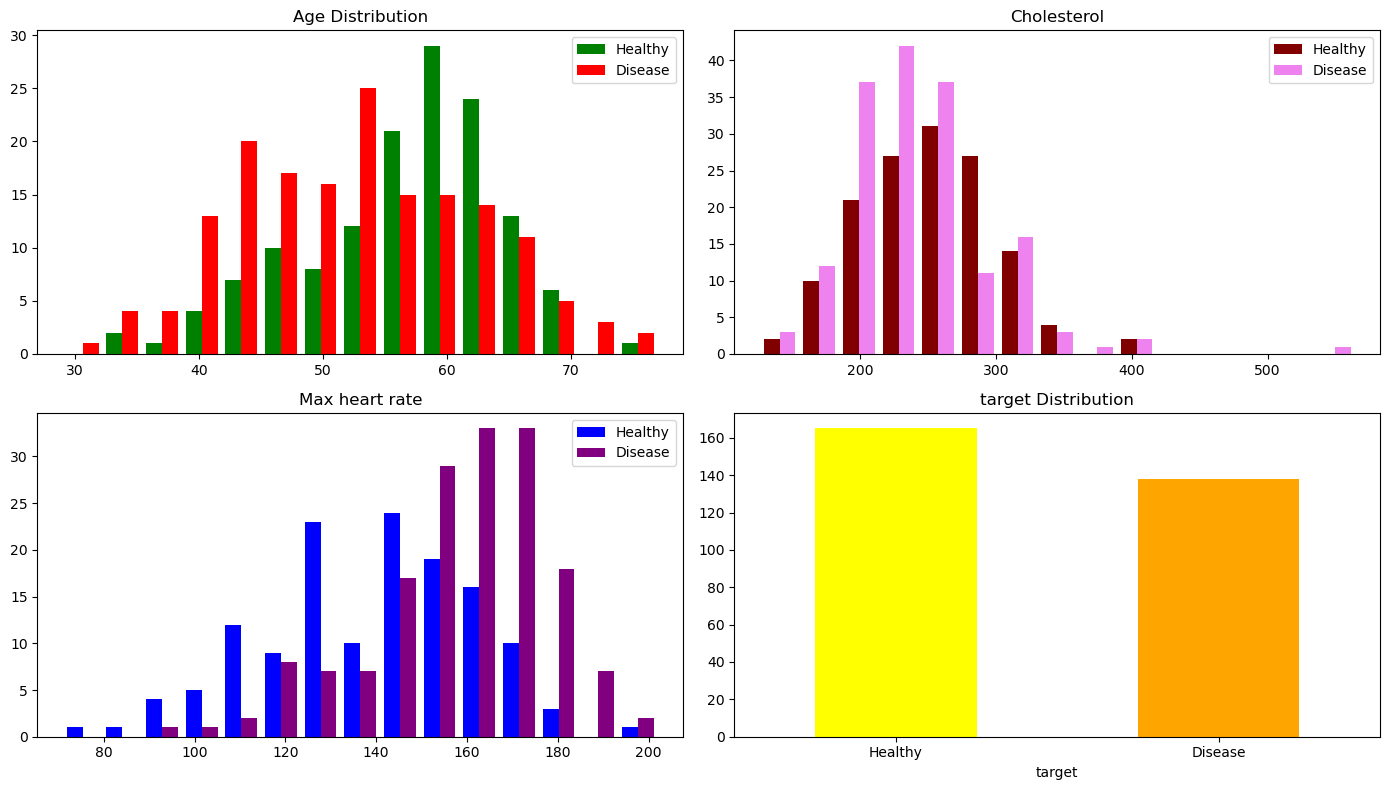

In [8]:
# Histograms and Target Distribution
fig, axes = plt.subplots(2, 2, figsize=(14,8))

axes[0,0].hist([df[df['target']==0]['age'], df[df['target']==1]['age']],
                label=['Healthy','Disease'], bins=15, color=['green','red'])
axes[0, 0].set_title('Age Distribution')
axes[0,0].legend()

axes[0,1].hist([df[df['target']==0]['chol'], df[df['target']==1]['chol']],
                label=['Healthy','Disease'], bins=15, color=['maroon','violet'])
axes[0,1].set_title('Cholesterol')
axes[0,1].legend()

axes[1,0].hist([df[df['target']==0]['thalach'], df[df['target']==1]['thalach']],
                label=['Healthy','Disease'], bins=15, color=['blue','purple'])
axes[1,0].set_title('Max heart rate')
axes[1,0].legend()

df['target'].value_counts().plot(kind='bar', ax=axes[1,1], color=['yellow','orange'])
axes[1,1].set_title('target Distribution')
axes[1,1].set_xticklabels(['Healthy','Disease'], rotation=0)

plt.tight_layout()
plt.show()

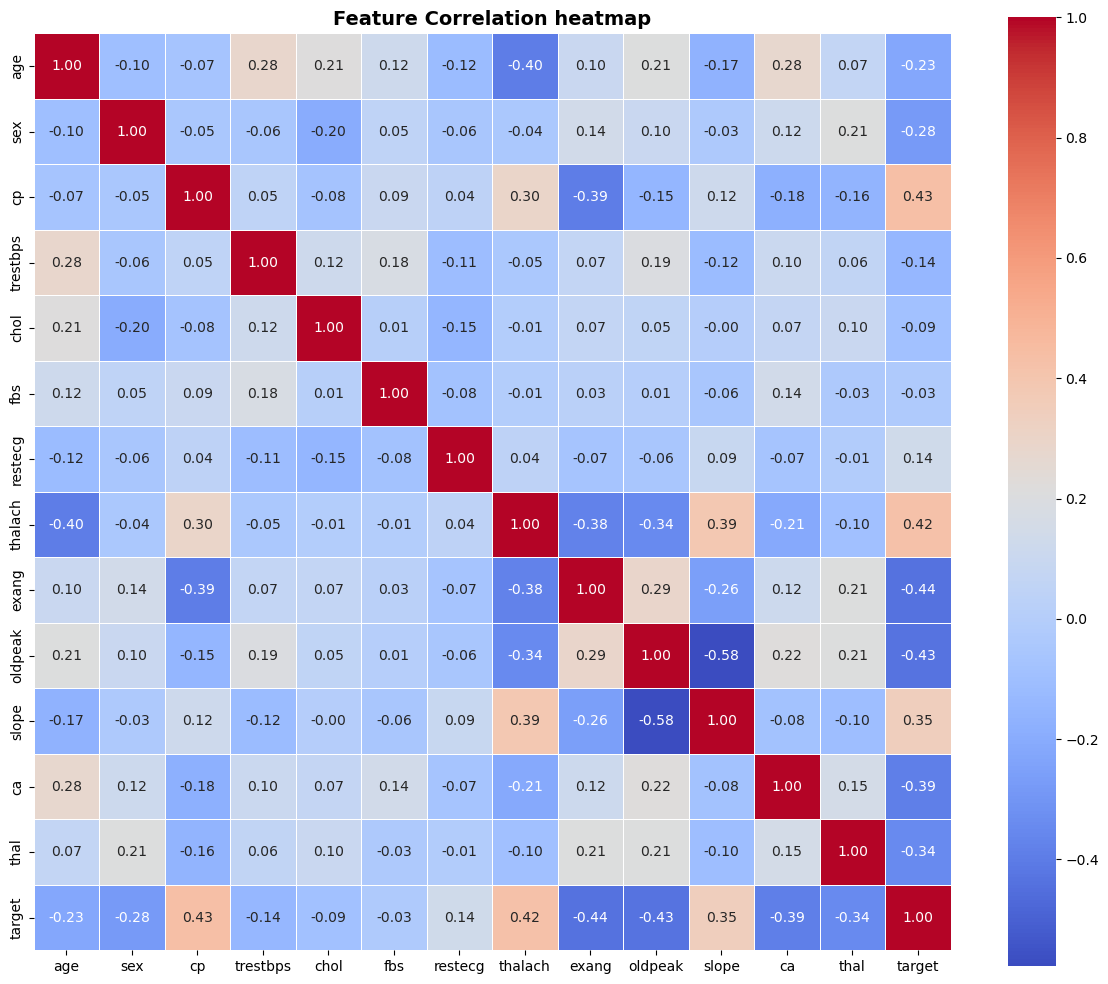

In [9]:
# Correlation Heatmap
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5, square=True)
plt.title('Feature Correlation heatmap',fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 5: Data Modelling

In [11]:
# Check the data shape

x = df.drop(columns='target', axis=1)
y = df['target']

print(x.shape)
print(y.shape)

(303, 13)
(303,)


In [12]:
# Train-test spli

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, stratify=y, random_state=42)

print(x_train.shape[0])
print(x_test.shape[0])

242
61


In [13]:
# Scale the data

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

joblib.dump(scaler, 'heart_scaler.pkl')

['heart_scaler.pkl']

In [15]:
# Data modelling - Logistic Regression

model = LogisticRegression(max_iter=100000, random_state=42)
score = cross_val_score(model, x_train_scaled, y_train, cv=5, scoring='accuracy')
print(f"{score.mean():.2f} (+/- {score.std():.4f})")

0.83 (+/- 0.0409)


In [16]:
# Model training 

model.fit(x_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,100000
,multi_class,'deprecated'


In [17]:
# Data prediction 

y_train_pred = model.predict(x_train_scaled)
y_test_pred = model.predict(x_test_scaled)

train_acc = accuracy_score(y_train, y_train)
test_acc = accuracy_score(y_test, y_test_pred)

print(f"Train Accuracy: {train_acc:.2f}")
print(f"Test Accuracy: {test_acc:.2f}")

print(classification_report(y_test, y_test_pred, target_names=['Healthy', 'Disease']))

Train Accuracy: 1.00
Test Accuracy: 0.80
              precision    recall  f1-score   support

     Healthy       0.86      0.68      0.76        28
     Disease       0.77      0.91      0.83        33

    accuracy                           0.80        61
   macro avg       0.82      0.79      0.80        61
weighted avg       0.81      0.80      0.80        61



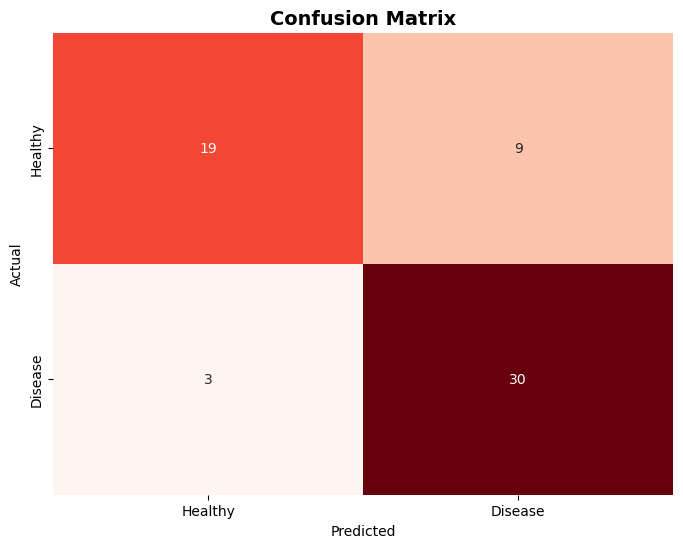

In [19]:
# Confusion matrix 

cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', cbar=False, xticklabels=['Healthy', 'Disease'], yticklabels=['Healthy', 'Disease'])
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [20]:
# Save the model

model_data = {
    "model": model,
    "feature_names": x.columns.tolist()
}

joblib.dump(model_data, "../model/heart_disease_model.pkl")

['../model/heart_disease_model.pkl']